# Embedding Space Analysis — Raw Feature Space vs ANN Learned Embedding

Bu notebook, **hand-crafted feature space** ile aynı örneklerin **ANN embedding layer** çıktısını karşılaştırmak için hazırlanmıştır.

Temel amaç yalnızca ANN embedding uzayını göstermek değildir. Asıl amaç şudur:

> Aynı öznitelikler ANN'e hiç sokulmadan kullanıldığında nasıl bir temsil/embedding space oluşturuyor; ANN'in supervised embedding layer'ı bu yapıyı nasıl değiştiriyor?

Bu nedenle her feature konfigürasyonu için iki temsil birlikte analiz edilir:

1. **Raw 42-feature space** → ANN'e girmeden önceki, sadece standardize edilmiş 42 özellikli temsil.
2. **ANN embedding, 42 features** → 42 özellikli modelin softmax öncesi 64-boyutlu embedding layer çıktısı.
3. **Raw top-20 feature space** → ANN'e girmeden önceki, sadece standardize edilmiş top-20 özellikli temsil.
4. **ANN embedding, top-20 features** → top-20 modelinin 64-boyutlu embedding layer çıktısı.
5. **Raw top-10 feature space** → ANN'e girmeden önceki, sadece standardize edilmiş top-10 özellikli temsil.
6. **ANN embedding, top-10 features** → top-10 modelinin 64-boyutlu embedding layer çıktısı.

Notebook çıktıları:

- Raw feature space vs ANN learned embedding karşılaştırması
- Silhouette ve Davies–Bouldin metrikleri
- Intra-class / inter-class distance ve separation ratio
- Top-1 retrieval ve Precision@5
- PCA ve t-SNE görselleri
- Per-class retrieval tabloları
- Makalede kullanılabilecek birleşik özet tablolar

> Not: Bu notebook eğitim yapmaz. Eğitim notebook'larında üretilen `best_*.h5`, `scaler_*.joblib` ve feature-list dosyalarını kullanır.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports and global configuration

In [5]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------------
# PATHS — edit if your Drive layout is different
# ------------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/FeatureImportanceAnalysisGüncel/one_shot_features_clean_V4.csv'

DIR_42 = '/content/drive/MyDrive/SavedModels/42feats_runs'
DIR_20 = '/content/drive/MyDrive/SavedModels/20feats_runs'
DIR_10 = '/content/drive/MyDrive/SavedModels/10feats_runs'

OUT_DIR = '/content/drive/MyDrive/SavedModels/embedding_space_analysis'
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Split configuration — must match training notebooks
# ------------------------------------------------------------------
SPLIT_SEED = 42
TEST_SIZE = 0.20

# ------------------------------------------------------------------
# t-SNE configuration
# ------------------------------------------------------------------
TSNE_RANDOM_STATE = 42
TSNE_PERPLEXITY = 30

## 2. Load data and recreate the validation split

In [6]:
df = pd.read_csv(CSV_PATH)

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist()[:10], '...')

# Same preprocessing logic as training notebooks:
# Numeric missing values are imputed with column-wise mean.
df_filled = df.copy()
numeric_columns = df_filled.select_dtypes(include=[np.number]).columns
df_filled[numeric_columns] = (
    df_filled[numeric_columns].fillna(df_filled[numeric_columns].mean())
)

feature_cols = [c for c in df_filled.columns if c not in ('label', 'filename')]
X_all = df_filled[feature_cols].values
y = df_filled['label'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)

print('Feature matrix:', X_all.shape)
print('Number of features:', len(feature_cols))
print('Classes:', class_names)

# Recreate the same validation split used in training notebooks.
indices = np.arange(len(y_encoded))
train_idx, val_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SPLIT_SEED,
    stratify=y_encoded
)

y_val = y_encoded[val_idx]

print('Train samples:', len(train_idx))
print('Validation samples:', len(val_idx))

Dataset shape: (6435, 44)
Columns: ['mfcc01', 'mfcc02', 'mfcc03', 'mfcc04', 'mfcc05', 'mfcc06', 'mfcc07', 'mfcc08', 'mfcc09', 'mfcc10'] ...
Feature matrix: (6435, 42)
Number of features: 42
Classes: ['Bass', 'Clap', 'Cymbal', 'Hat', 'Kick', 'Rims', 'Snare']
Train samples: 5148
Validation samples: 1287


## 3. Load top-20 and top-10 feature lists

In [7]:
def load_feature_list(json_path, csv_path=None):
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            return json.load(f)
    if csv_path is not None and os.path.exists(csv_path):
        df_list = pd.read_csv(csv_path)
        if 'feature' in df_list.columns:
            return df_list['feature'].tolist()
        if 'name' in df_list.columns:
            return df_list['name'].tolist()
        return df_list.iloc[:, 0].tolist()
    raise FileNotFoundError(f'Feature list not found: {json_path}')

TOP20_FEATURES = load_feature_list(
    os.path.join(DIR_20, 'top20_features_used.json'),
    os.path.join(DIR_20, 'top20_features_used.csv')
)

TOP10_FEATURES = load_feature_list(
    os.path.join(DIR_10, 'top10_features_used.json'),
    os.path.join(DIR_10, 'top10_features_used.csv')
)

print('Top-20 features:', TOP20_FEATURES)
print('Top-10 features:', TOP10_FEATURES)

missing20 = [f for f in TOP20_FEATURES if f not in feature_cols]
missing10 = [f for f in TOP10_FEATURES if f not in feature_cols]

if missing20 or missing10:
    print('Missing in feature_cols:')
    print('Top-20 missing:', missing20)
    print('Top-10 missing:', missing10)
    raise ValueError('Some selected features are not present in the feature matrix.')

idx20 = [feature_cols.index(f) for f in TOP20_FEATURES]
idx10 = [feature_cols.index(f) for f in TOP10_FEATURES]

X_42 = X_all
X_20 = X_all[:, idx20]
X_10 = X_all[:, idx10]

print('X_42:', X_42.shape)
print('X_20:', X_20.shape)
print('X_10:', X_10.shape)

Top-20 features: ['onset_sum', 'rms_std', 'flux_mean', 'mfcc03', 'mfcc04', 'onset_std', 'contrast_b6', 'mfcc02', 'rms_mean', 'onset_mean', 'mfcc01', 'onset_max', 'contrast_b2', 'bandwidth_mean', 'zcr_mean', 'mfcc05', 'centroid_mean', 'mfcc08', 'rolloff_mean', 'flatness_mean']
Top-10 features: ['onset_sum', 'rms_std', 'flux_mean', 'mfcc03', 'mfcc04', 'onset_std', 'contrast_b6', 'mfcc02', 'rms_mean', 'onset_mean']
X_42: (6435, 42)
X_20: (6435, 20)
X_10: (6435, 10)


## 4. Load models and extract embedding-layer outputs

In [8]:
def get_embedding_model(model, layer_name='embedding_layer'):
    # Return a Keras model that outputs the embedding layer.
    try:
        embedding_output = model.get_layer(layer_name).output
    except ValueError:
        print(f'Layer "{layer_name}" not found. Using the penultimate layer instead.')
        embedding_output = model.layers[-2].output
    return Model(inputs=model.input, outputs=embedding_output)


def extract_raw_and_embedding(model_path, scaler_path, X, val_idx, name):
    print(f'\nProcessing: {name}')
    print('Model:', model_path)
    print('Scaler:', scaler_path)

    model = load_model(model_path, compile=False)
    scaler = joblib.load(scaler_path)

    X_scaled = scaler.transform(X)
    X_val_scaled = X_scaled[val_idx]

    emb_model = get_embedding_model(model)
    Z_val = emb_model.predict(X_val_scaled, batch_size=64, verbose=1)

    print(f'Raw validation space: {X_val_scaled.shape}')
    print(f'Embedding space:      {Z_val.shape}')

    return X_val_scaled, Z_val


X42_val, Z42 = extract_raw_and_embedding(
    model_path=os.path.join(DIR_42, 'best_42feats.h5'),
    scaler_path=os.path.join(DIR_42, 'scaler_42feats.joblib'),
    X=X_42,
    val_idx=val_idx,
    name='42 features'
)

X20_val, Z20 = extract_raw_and_embedding(
    model_path=os.path.join(DIR_20, 'best_20feats.h5'),
    scaler_path=os.path.join(DIR_20, 'scaler_20feats.joblib'),
    X=X_20,
    val_idx=val_idx,
    name='Top-20 features'
)

X10_val, Z10 = extract_raw_and_embedding(
    model_path=os.path.join(DIR_10, 'best_10feats.h5'),
    scaler_path=os.path.join(DIR_10, 'scaler_10feats.joblib'),
    X=X_10,
    val_idx=val_idx,
    name='Top-10 features'
)


Processing: 42 features
Model: /content/drive/MyDrive/SavedModels/42feats_runs/best_42feats.h5
Scaler: /content/drive/MyDrive/SavedModels/42feats_runs/scaler_42feats.joblib
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Raw validation space: (1287, 42)
Embedding space:      (1287, 64)

Processing: Top-20 features
Model: /content/drive/MyDrive/SavedModels/20feats_runs/best_20feats.h5
Scaler: /content/drive/MyDrive/SavedModels/20feats_runs/scaler_20feats.joblib
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Raw validation space: (1287, 20)
Embedding space:      (1287, 64)

Processing: Top-10 features
Model: /content/drive/MyDrive/SavedModels/10feats_runs/best_10feats.h5
Scaler: /content/drive/MyDrive/SavedModels/10feats_runs/scaler_10feats.joblib
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Raw validation space: (1287, 10)
Embedding space:      (1287, 64)


## 5. Geometry metrics

Bu bölüm, **ANN'e sokulmamış raw feature space** ve **ANN learned embedding space** için sınıf geometrisini birlikte ölçer.

- **Raw feature space**: Aynı özniteliklerin sinir ağına girmeden önce oluşturduğu başlangıç temsil uzayıdır.
- **ANN embedding space**: Eğitilmiş modelin softmax öncesi 64-boyutlu embedding layer çıktısıdır.

Metrikler:

- **Silhouette score (cosine)**: Yüksek olması daha iyi sınıf ayrışmasına işaret eder.
- **Davies–Bouldin index (Euclidean)**: Düşük olması daha iyi cluster yapısına işaret eder.


In [9]:
def compute_geometry_metrics(X_repr, y):
    return {
        'Silhouette (cosine)': silhouette_score(X_repr, y, metric='cosine'),
        'Davies-Bouldin (euclidean)': davies_bouldin_score(X_repr, y),
    }


raw_spaces = {
    'Raw 42 features': X42_val,
    'Raw Top-20 features': X20_val,
    'Raw Top-10 features': X10_val,
}

embedding_spaces = {
    'ANN Embedding 42 features': Z42,
    'ANN Embedding Top-20 features': Z20,
    'ANN Embedding Top-10 features': Z10,
}

spaces_all = {
    **raw_spaces,
    **embedding_spaces,
}

geometry_rows = []
for name, X_repr in spaces_all.items():
    row = compute_geometry_metrics(X_repr, y_val)
    row['Representation'] = name
    row['Space type'] = 'Raw feature space' if name.startswith('Raw') else 'ANN learned embedding'
    geometry_rows.append(row)

geometry_df = pd.DataFrame(geometry_rows)
geometry_df = geometry_df[
    ['Representation', 'Space type', 'Silhouette (cosine)', 'Davies-Bouldin (euclidean)']
]

display(geometry_df)

geometry_path = os.path.join(OUT_DIR, 'embedding_geometry_metrics_raw_and_ann.csv')
geometry_df.to_csv(geometry_path, index=False)
print('Saved:', geometry_path)


,Representation,Space type,Silhouette (cosine),Davies-Bouldin (euclidean)
0,Raw 42 features,Raw feature space,0.057961,4.013475
1,Raw Top-20 features,Raw feature space,0.056989,3.368461
2,Raw Top-10 features,Raw feature space,0.047200,3.019261
3,ANN Embedding 42 features,ANN learned embedding,0.513350,1.159713
4,ANN Embedding Top-20 features,ANN learned embedding,0.486015,1.263025
5,ANN Embedding Top-10 features,ANN learned embedding,0.385481,1.534650


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/embedding_geometry_metrics_raw_and_ann.csv


## 6. Intra-class / inter-class distance analysis

Bu bölüm cosine distance üzerinden sınıf-içi ve sınıflar-arası mesafeleri hesaplar.

- **Intra-class distance** düşükse aynı sınıfa ait örnekler daha yakındır.
- **Inter-class distance** yüksekse farklı sınıflar daha uzaktır.
- **Separation ratio** = inter-class / intra-class. Yüksek olması daha iyi ayrışmaya işaret eder.

In [10]:
def intra_inter_distance_analysis(X_repr, y):
    D = cosine_distances(X_repr)
    y = np.asarray(y)

    intra_values = []
    inter_values = []

    for i in range(len(y)):
        same = (y == y[i]).copy()
        diff = (y != y[i])
        same[i] = False

        intra_values.extend(D[i, same])
        inter_values.extend(D[i, diff])

    intra_mean = float(np.mean(intra_values))
    inter_mean = float(np.mean(inter_values))
    sep_ratio = inter_mean / intra_mean

    return {
        'Intra-class distance': intra_mean,
        'Inter-class distance': inter_mean,
        'Separation ratio': sep_ratio,
    }


distance_rows = []
for name, X_repr in spaces_all.items():
    row = intra_inter_distance_analysis(X_repr, y_val)
    row['Representation'] = name
    distance_rows.append(row)

distance_df = pd.DataFrame(distance_rows)
distance_df = distance_df[
    ['Representation', 'Intra-class distance', 'Inter-class distance', 'Separation ratio']
]

display(distance_df)

distance_path = os.path.join(OUT_DIR, 'embedding_distance_metrics.csv')
distance_df.to_csv(distance_path, index=False)
print('Saved:', distance_path)

,Representation,Intra-class distance,Inter-class distance,Separation ratio
0,Raw 42 features,0.667881,1.062871,1.591407
1,Raw Top-20 features,0.640061,1.065587,1.664822
2,Raw Top-10 features,0.657772,1.050632,1.597259
3,ANN Embedding 42 features,0.224706,0.759417,3.379600
4,ANN Embedding Top-20 features,0.241134,0.762440,3.161898
5,ANN Embedding Top-10 features,0.285505,0.749915,2.626630


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/embedding_distance_metrics.csv


## 7. Nearest-neighbour retrieval metrics

Bu bölüm, hem raw feature space'in hem de ANN embedding space'in sample organisation / similarity retrieval açısından ne kadar anlamlı olduğunu test eder.

Her örnek query olarak alınır. Cosine distance ile en yakın komşular bulunur.

- **Top-1 retrieval**: En yakın komşunun aynı sınıftan olma oranı.
- **Precision@5**: En yakın 5 komşu içinde aynı sınıftan olanların ortalama oranı.

Bu analiz, "hand-crafted feature space zaten anlamlı bir timbral organisation sağlıyor mu, ANN embedding layer bu yapıyı iyileştiriyor mu?" sorusuna doğrudan cevap verir.


In [11]:
def retrieval_metrics(X_repr, y, k=5):
    y = np.asarray(y)

    nn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    nn.fit(X_repr)

    distances, indices = nn.kneighbors(X_repr)

    # First neighbour is the query itself.
    neighbour_indices = indices[:, 1:]

    precision_at_k = []
    top1_correct = []

    for i in range(len(y)):
        retrieved_labels = y[neighbour_indices[i]]
        query_label = y[i]

        precision_at_k.append(np.mean(retrieved_labels == query_label))
        top1_correct.append(retrieved_labels[0] == query_label)

    return {
        f'Precision@{k}': float(np.mean(precision_at_k)),
        'Top-1 retrieval': float(np.mean(top1_correct)),
    }


retrieval_rows = []
for name, X_repr in spaces_all.items():
    row = retrieval_metrics(X_repr, y_val, k=5)
    row['Representation'] = name
    row['Space type'] = 'Raw feature space' if name.startswith('Raw') else 'ANN learned embedding'
    retrieval_rows.append(row)

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df = retrieval_df[['Representation', 'Space type', 'Top-1 retrieval', 'Precision@5']]

display(retrieval_df)

retrieval_path = os.path.join(OUT_DIR, 'embedding_retrieval_metrics_raw_and_ann.csv')
retrieval_df.to_csv(retrieval_path, index=False)
print('Saved:', retrieval_path)


,Representation,Space type,Top-1 retrieval,Precision@5
0,Raw 42 features,Raw feature space,0.769231,0.697747
1,Raw Top-20 features,Raw feature space,0.763792,0.710023
2,Raw Top-10 features,Raw feature space,0.746698,0.677234
3,ANN Embedding 42 features,ANN learned embedding,0.874126,0.861072
4,ANN Embedding Top-20 features,ANN learned embedding,0.876457,0.862005
5,ANN Embedding Top-10 features,ANN learned embedding,0.836053,0.824398


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/embedding_retrieval_metrics_raw_and_ann.csv


## 8. 2D visualisation functions

In [12]:
def project_pca(X_repr):
    pca = PCA(n_components=2, random_state=42)
    return pca.fit_transform(X_repr)


def project_tsne(X_repr):
    tsne = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        learning_rate='auto',
        init='pca',
        random_state=TSNE_RANDOM_STATE
    )
    return tsne.fit_transform(X_repr)


def plot_projection_grid(projections, y, titles, save_path=None, ncols=None):
    n = len(projections)
    if ncols is None:
        ncols = n
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.2 * nrows), dpi=150)

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    axes_flat = axes.flatten()

    for ax_idx, ax in enumerate(axes_flat):
        if ax_idx >= n:
            ax.axis('off')
            continue

        X_2d = projections[ax_idx]
        title = titles[ax_idx]

        for class_id, class_name in enumerate(class_names):
            mask = y == class_id
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                s=10,
                alpha=0.70,
                label=class_name
            )

        ax.set_title(title)
        ax.set_xlabel('Dimension 1')
        ax.set_ylabel('Dimension 2')

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        fontsize=8,
        markerscale=2
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print('Saved:', save_path)

    plt.show()


## 9. PCA visualisations

PCA deterministik ve hızlıdır. Makalede t-SNE'ye ek olarak kontrol amaçlı kullanılabilir.

Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/pca_raw_vs_ann_all_feature_sets.png


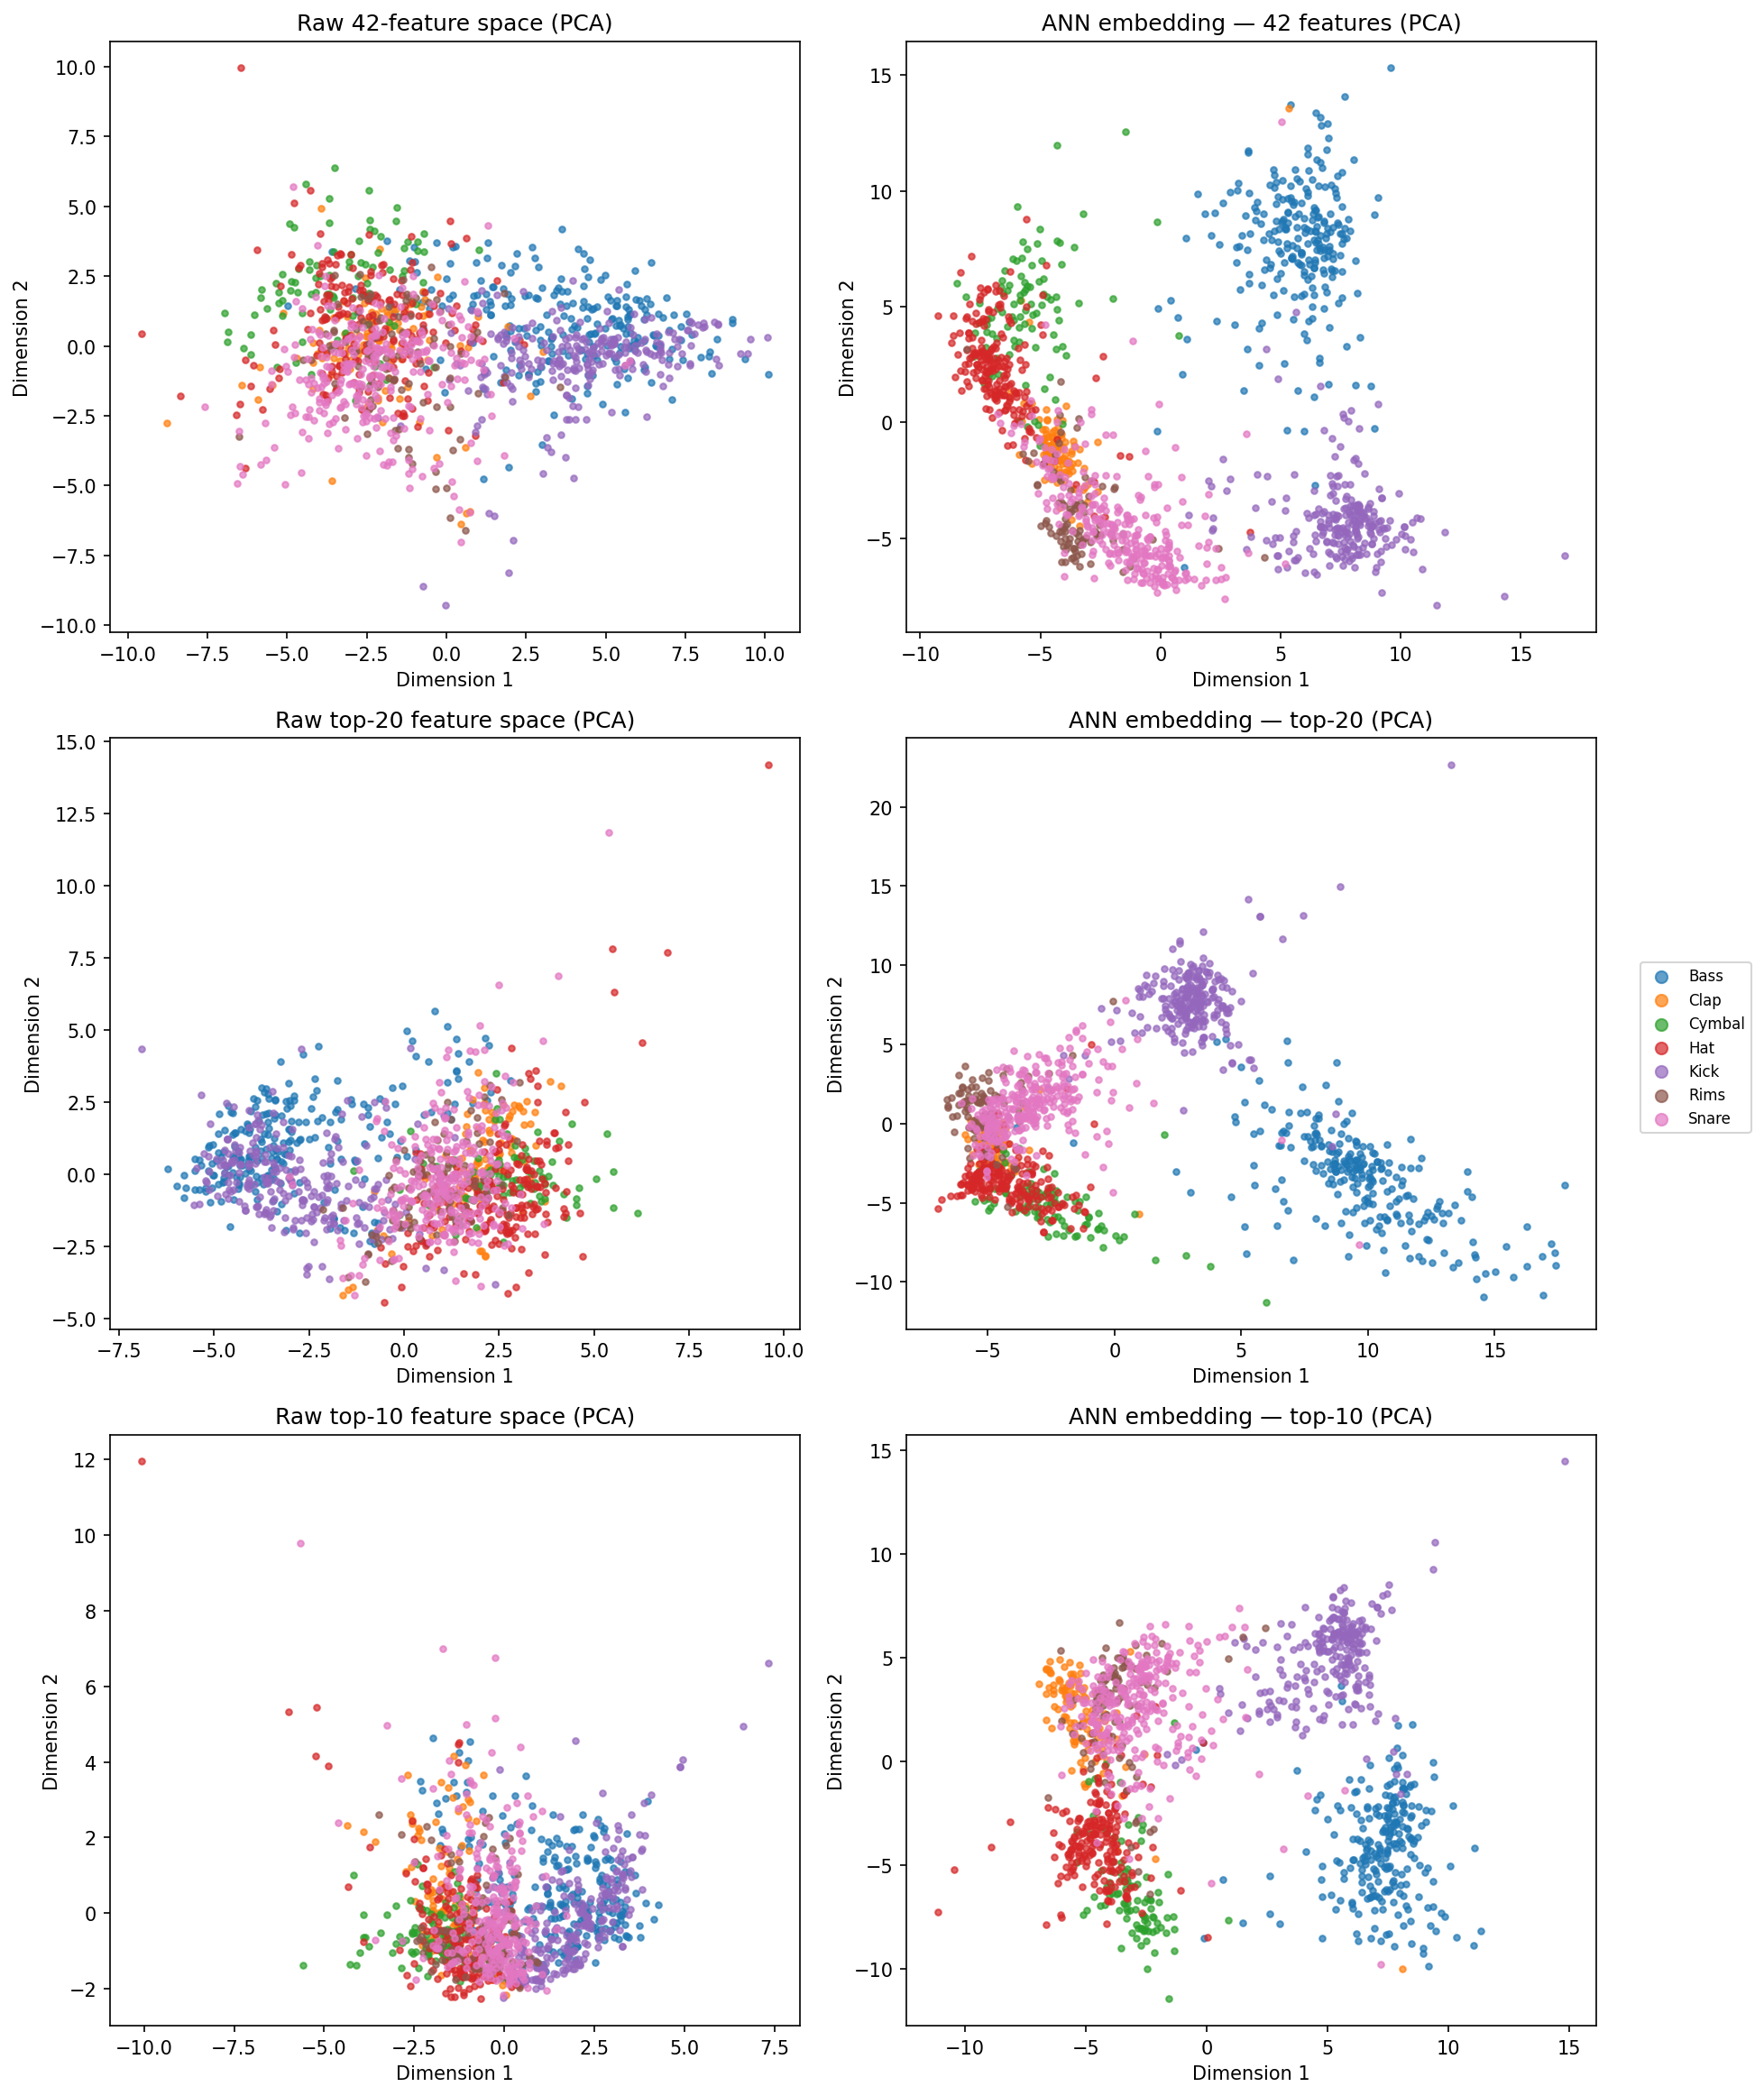

Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/pca_ann_embeddings_42_20_10.png


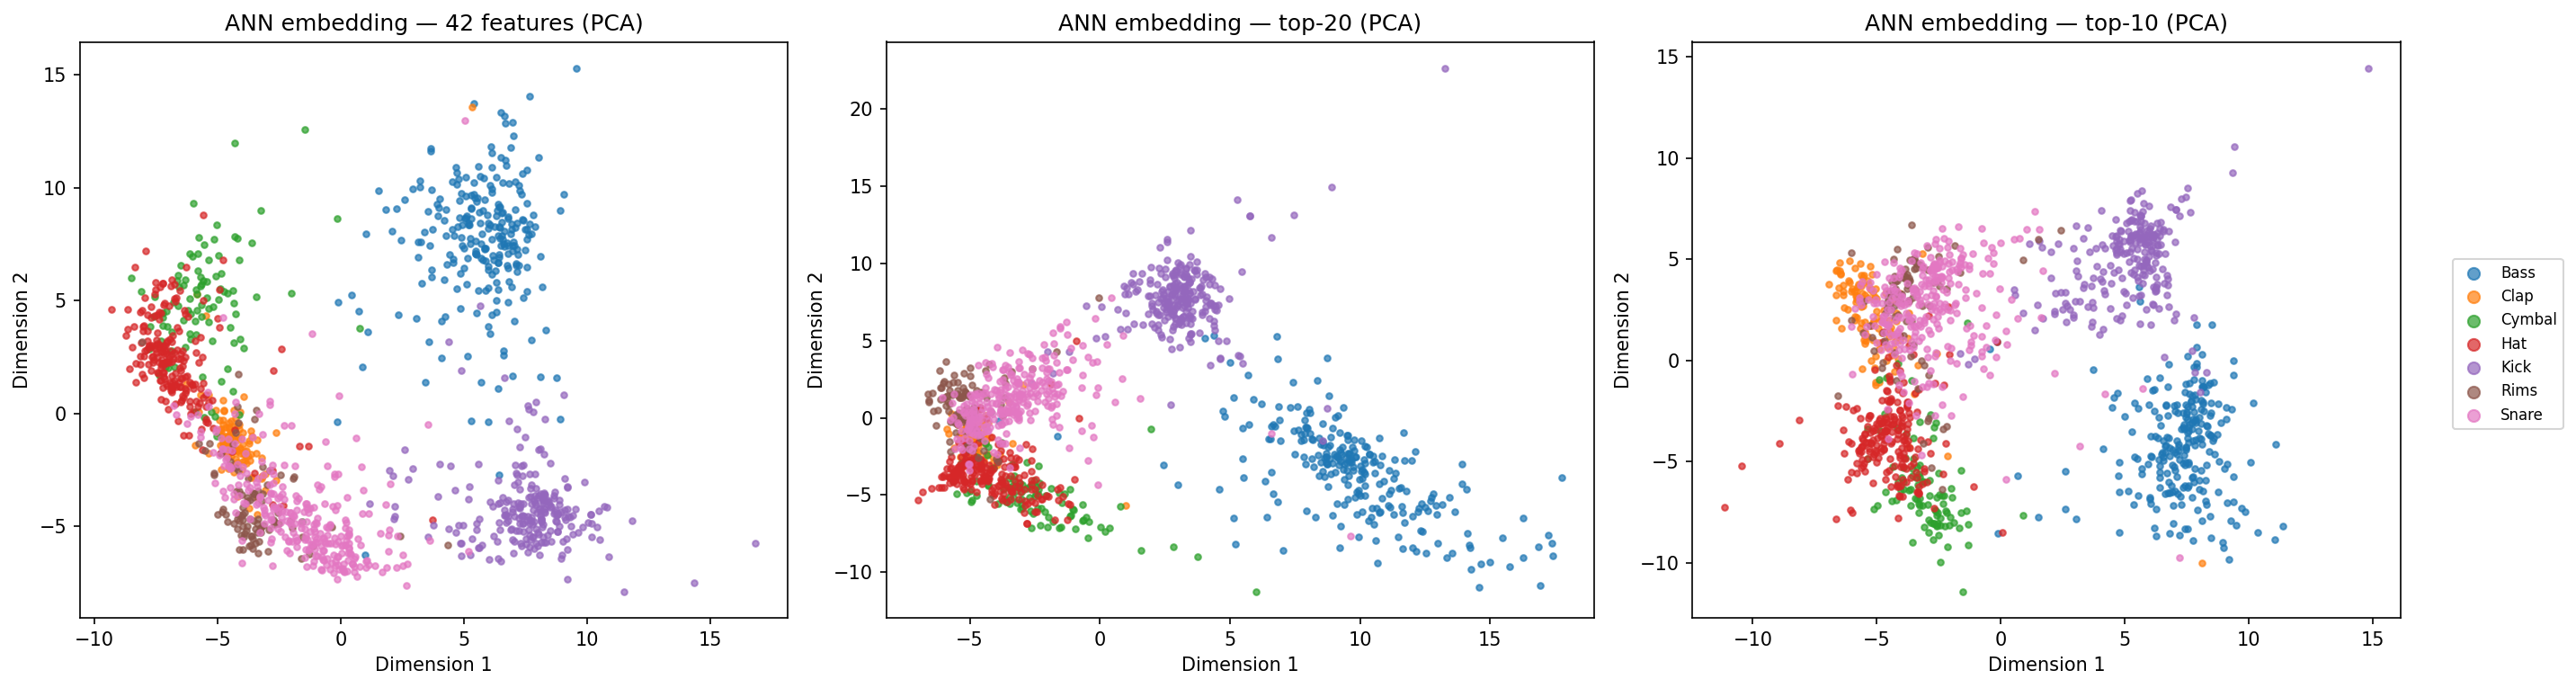

In [13]:
# PCA projections for all raw and ANN spaces
pca_raw42 = project_pca(X42_val)
pca_emb42 = project_pca(Z42)

pca_raw20 = project_pca(X20_val)
pca_emb20 = project_pca(Z20)

pca_raw10 = project_pca(X10_val)
pca_emb10 = project_pca(Z10)

# Main comparison: raw handcrafted spaces vs ANN learned embeddings
plot_projection_grid(
    [pca_raw42, pca_emb42, pca_raw20, pca_emb20, pca_raw10, pca_emb10],
    y_val,
    [
        'Raw 42-feature space (PCA)',
        'ANN embedding — 42 features (PCA)',
        'Raw top-20 feature space (PCA)',
        'ANN embedding — top-20 (PCA)',
        'Raw top-10 feature space (PCA)',
        'ANN embedding — top-10 (PCA)'
    ],
    save_path=os.path.join(OUT_DIR, 'pca_raw_vs_ann_all_feature_sets.png'),
    ncols=2
)

# Compact figure: ANN embedding comparison across feature subsets
plot_projection_grid(
    [pca_emb42, pca_emb20, pca_emb10],
    y_val,
    ['ANN embedding — 42 features (PCA)', 'ANN embedding — top-20 (PCA)', 'ANN embedding — top-10 (PCA)'],
    save_path=os.path.join(OUT_DIR, 'pca_ann_embeddings_42_20_10.png'),
    ncols=3
)


## 10. t-SNE visualisations

t-SNE görsel ayrımı daha belirgin gösterebilir; ancak makalede bu görselleri **nicel metriklerin destekleyicisi** olarak kullanmak daha güvenlidir.

Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/tsne_raw_vs_ann_all_feature_sets.png


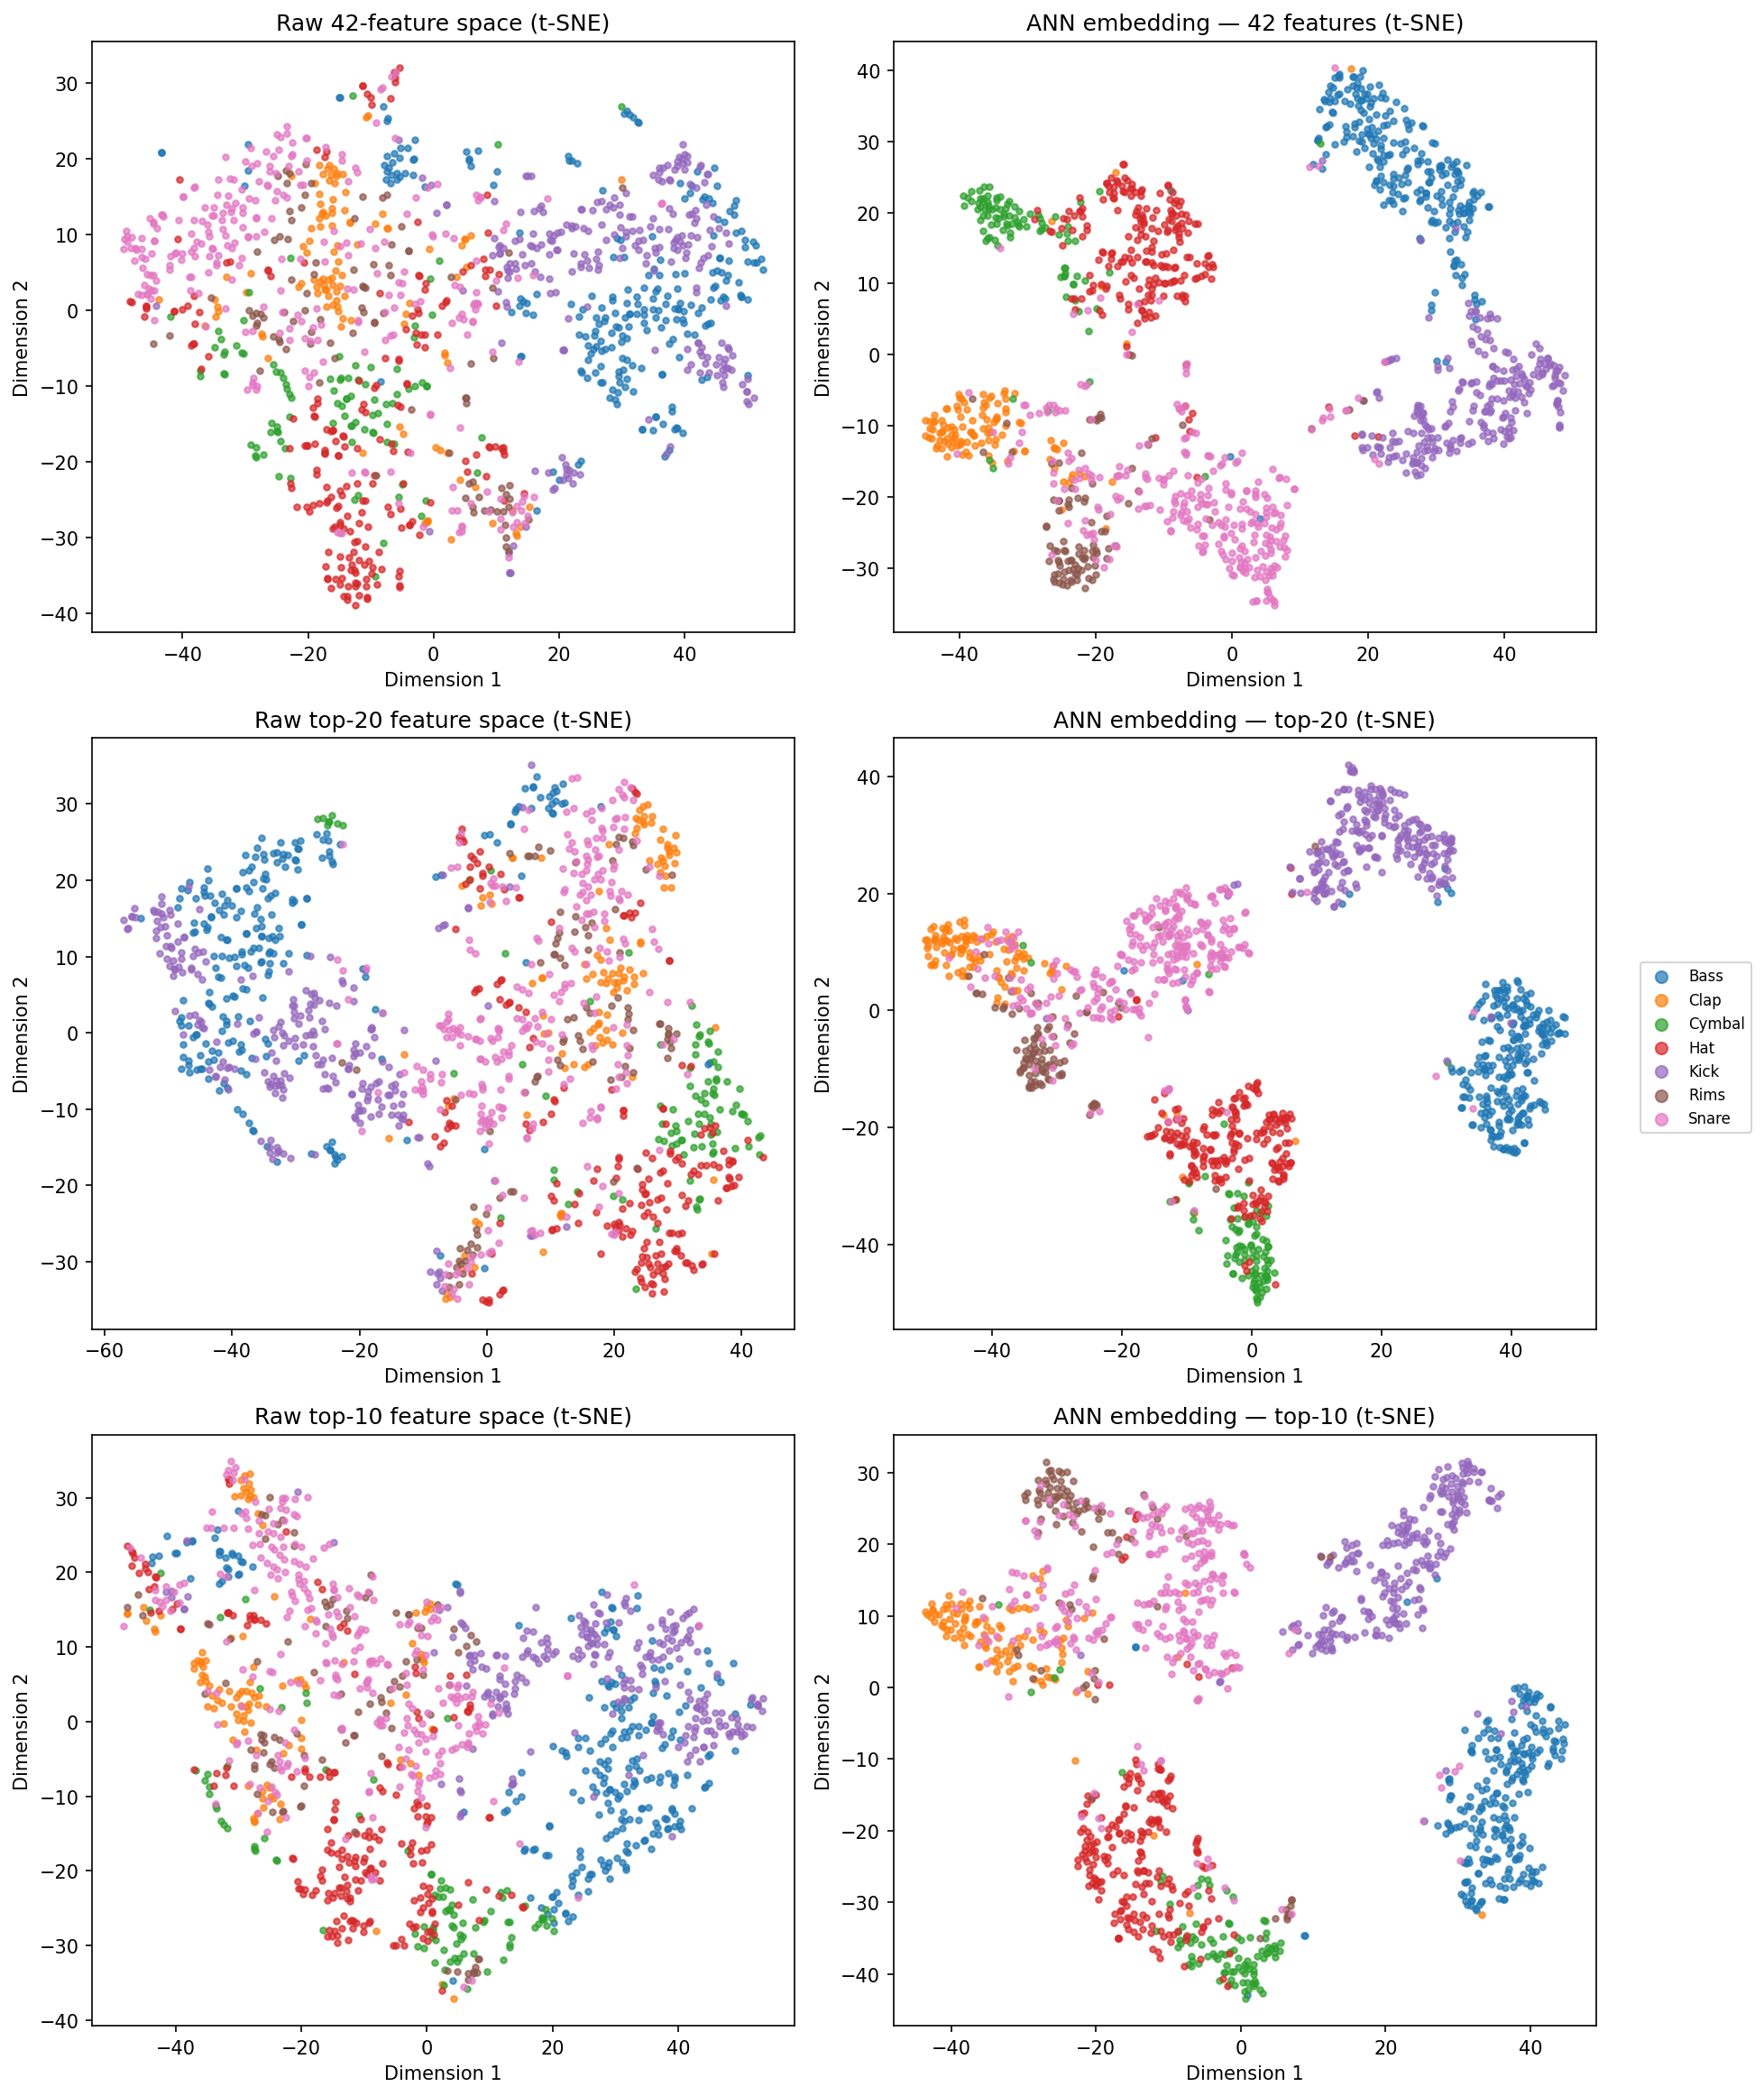

Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/tsne_ann_embeddings_42_20_10.png


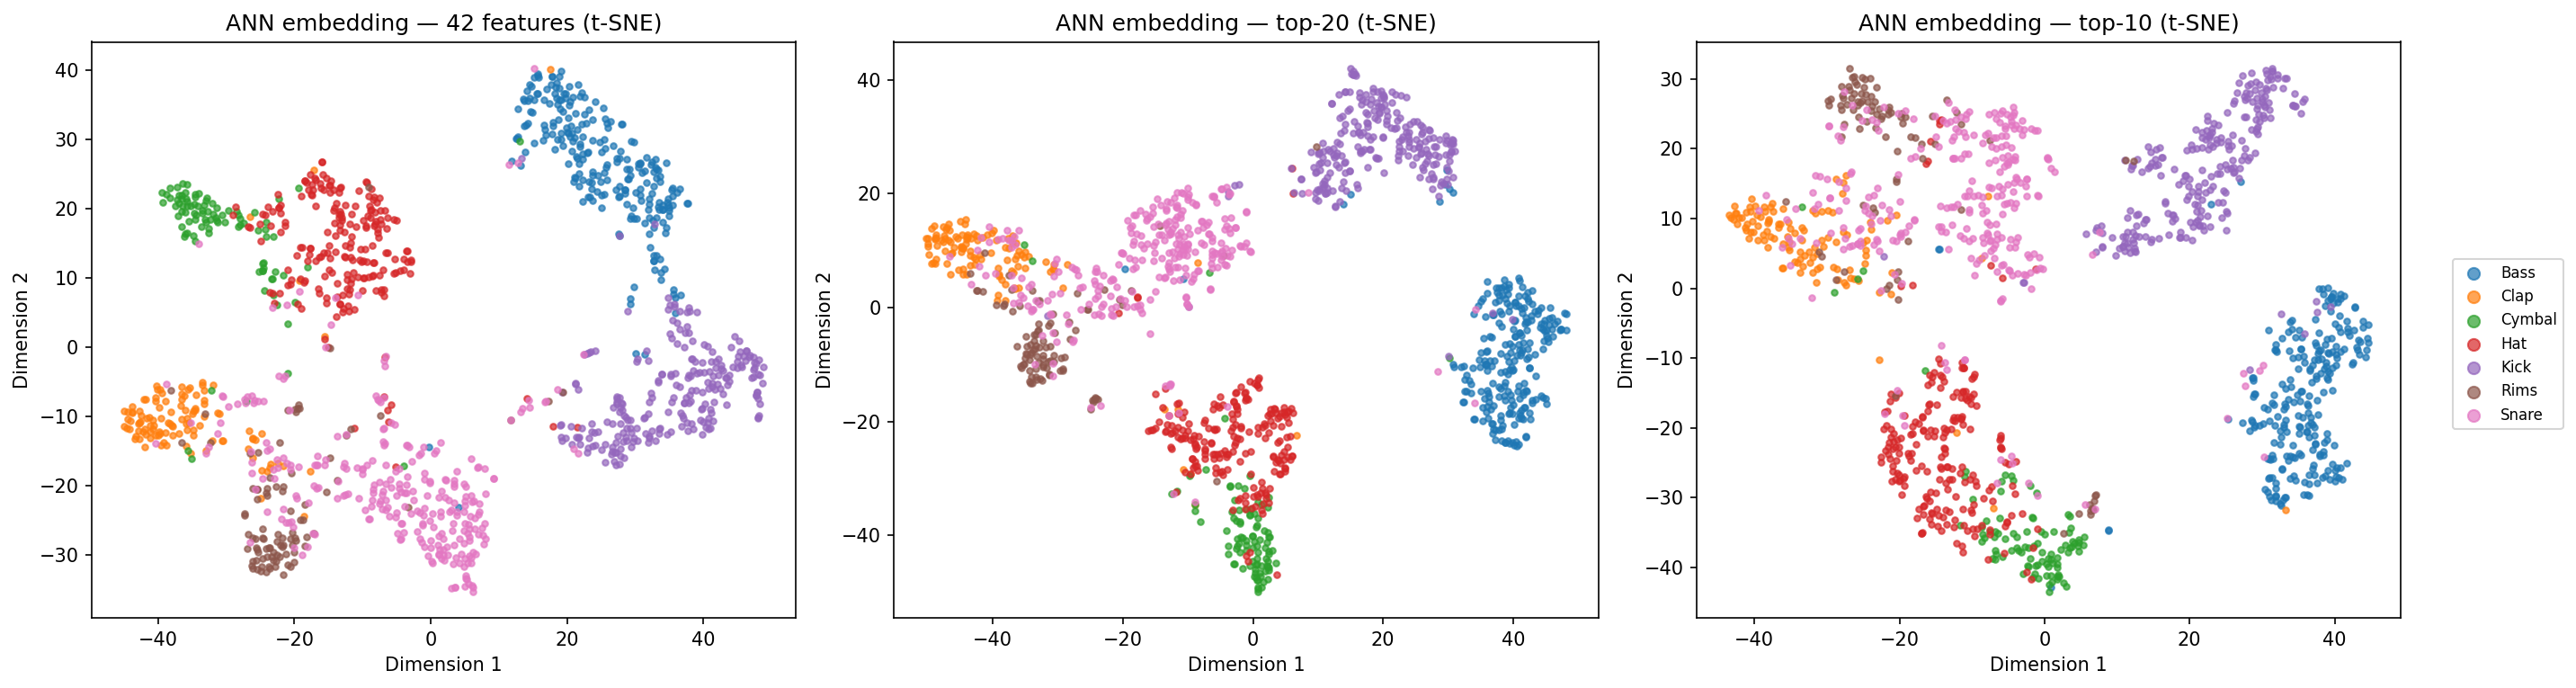

In [14]:
# t-SNE projections for all raw and ANN spaces
# This may take a few minutes.
tsne_raw42 = project_tsne(X42_val)
tsne_emb42 = project_tsne(Z42)

tsne_raw20 = project_tsne(X20_val)
tsne_emb20 = project_tsne(Z20)

tsne_raw10 = project_tsne(X10_val)
tsne_emb10 = project_tsne(Z10)

# Main comparison: raw handcrafted spaces vs ANN learned embeddings
plot_projection_grid(
    [tsne_raw42, tsne_emb42, tsne_raw20, tsne_emb20, tsne_raw10, tsne_emb10],
    y_val,
    [
        'Raw 42-feature space (t-SNE)',
        'ANN embedding — 42 features (t-SNE)',
        'Raw top-20 feature space (t-SNE)',
        'ANN embedding — top-20 (t-SNE)',
        'Raw top-10 feature space (t-SNE)',
        'ANN embedding — top-10 (t-SNE)'
    ],
    save_path=os.path.join(OUT_DIR, 'tsne_raw_vs_ann_all_feature_sets.png'),
    ncols=2
)

# Compact figure: ANN embedding comparison across feature subsets
plot_projection_grid(
    [tsne_emb42, tsne_emb20, tsne_emb10],
    y_val,
    ['ANN embedding — 42 features (t-SNE)', 'ANN embedding — top-20 (t-SNE)', 'ANN embedding — top-10 (t-SNE)'],
    save_path=os.path.join(OUT_DIR, 'tsne_ann_embeddings_42_20_10.png'),
    ncols=3
)


## 11. Optional: per-class retrieval performance

Bu tablo hangi sınıflarda nearest-neighbour organisation'ın daha güçlü veya zayıf olduğunu gösterir. Confusion matrix'teki sınıf çiftleriyle birlikte yorumlanabilir.

In [15]:
def per_class_retrieval_metrics(X_repr, y, k=5):
    y = np.asarray(y)

    nn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    nn.fit(X_repr)
    distances, indices = nn.kneighbors(X_repr)
    neighbour_indices = indices[:, 1:]

    rows = []

    for class_id, class_name in enumerate(class_names):
        query_indices = np.where(y == class_id)[0]

        p_at_k = []
        top1 = []

        for i in query_indices:
            retrieved_labels = y[neighbour_indices[i]]
            query_label = y[i]

            p_at_k.append(np.mean(retrieved_labels == query_label))
            top1.append(retrieved_labels[0] == query_label)

        rows.append({
            'Class': class_name,
            'Support': len(query_indices),
            'Top-1 retrieval': float(np.mean(top1)),
            f'Precision@{k}': float(np.mean(p_at_k)),
        })

    return pd.DataFrame(rows)


# Per-class retrieval for all spaces. This can be useful for connecting embedding
# structure to confusion-matrix patterns.
per_class_tables = {}

for name, X_repr in spaces_all.items():
    print('\n', name)
    df_pc = per_class_retrieval_metrics(X_repr, y_val, k=5)
    df_pc.insert(0, 'Representation', name)
    df_pc.insert(1, 'Space type', 'Raw feature space' if name.startswith('Raw') else 'ANN learned embedding')
    display(df_pc)

    safe_name = (
        name.lower()
        .replace(' ', '_')
        .replace('—', '')
        .replace('-', '_')
    )
    out_path = os.path.join(OUT_DIR, f'per_class_retrieval_{safe_name}.csv')
    df_pc.to_csv(out_path, index=False)
    print('Saved:', out_path)

    per_class_tables[name] = df_pc

per_class_all = pd.concat(per_class_tables.values(), ignore_index=True)
per_class_all_path = os.path.join(OUT_DIR, 'per_class_retrieval_all_spaces.csv')
per_class_all.to_csv(per_class_all_path, index=False)
print('Saved combined table:', per_class_all_path)



 Raw 42 features


,Representation,Space type,Class,Support,Top-1 retrieval,Precision@5
0,Raw 42 features,Raw feature space,Bass,242,0.830579,0.787603
1,Raw 42 features,Raw feature space,Clap,114,0.771930,0.685965
2,Raw 42 features,Raw feature space,Cymbal,96,0.697917,0.595833
3,Raw 42 features,Raw feature space,Hat,210,0.838095,0.696190
4,Raw 42 features,Raw feature space,Kick,241,0.883817,0.840664
5,Raw 42 features,Raw feature space,Rims,95,0.431579,0.320000
6,Raw 42 features,Raw feature space,Snare,289,0.705882,0.667128


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_raw_42_features.csv

 Raw Top-20 features


,Representation,Space type,Class,Support,Top-1 retrieval,Precision@5
0,Raw Top-20 features,Raw feature space,Bass,242,0.859504,0.798347
1,Raw Top-20 features,Raw feature space,Clap,114,0.728070,0.689474
2,Raw Top-20 features,Raw feature space,Cymbal,96,0.677083,0.639583
3,Raw Top-20 features,Raw feature space,Hat,210,0.847619,0.767619
4,Raw Top-20 features,Raw feature space,Kick,241,0.871369,0.827386
5,Raw Top-20 features,Raw feature space,Rims,95,0.526316,0.400000
6,Raw Top-20 features,Raw feature space,Snare,289,0.653979,0.629758


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_raw_top_20_features.csv

 Raw Top-10 features


...

Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_ann_embedding_42_features.csv

 ANN Embedding Top-20 features


,Representation,Space type,Class,Support,Top-1 retrieval,Precision@5
0,ANN Embedding Top-20 features,ANN learned embedding,Bass,242,0.966942,0.953719
1,ANN Embedding Top-20 features,ANN learned embedding,Clap,114,0.807018,0.791228
2,ANN Embedding Top-20 features,ANN learned embedding,Cymbal,96,0.822917,0.787500
3,ANN Embedding Top-20 features,ANN learned embedding,Hat,210,0.885714,0.884762
4,ANN Embedding Top-20 features,ANN learned embedding,Kick,241,0.954357,0.954357
5,ANN Embedding Top-20 features,ANN learned embedding,Rims,95,0.747368,0.730526
6,ANN Embedding Top-20 features,ANN learned embedding,Snare,289,0.816609,0.787543


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_ann_embedding_top_20_features.csv

 ANN Embedding Top-10 features


,Representation,Space type,Class,Support,Top-1 retrieval,Precision@5
0,ANN Embedding Top-10 features,ANN learned embedding,Bass,242,0.971074,0.955372
1,ANN Embedding Top-10 features,ANN learned embedding,Clap,114,0.728070,0.708772
2,ANN Embedding Top-10 features,ANN learned embedding,Cymbal,96,0.781250,0.770833
3,ANN Embedding Top-10 features,ANN learned embedding,Hat,210,0.847619,0.837143
4,ANN Embedding Top-10 features,ANN learned embedding,Kick,241,0.958506,0.952697
5,ANN Embedding Top-10 features,ANN learned embedding,Rims,95,0.621053,0.642105
6,ANN Embedding Top-10 features,ANN learned embedding,Snare,289,0.743945,0.721799


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_ann_embedding_top_10_features.csv
Saved combined table: /content/drive/MyDrive/SavedModels/embedding_space_analysis/per_class_retrieval_all_spaces.csv


## 12. Save combined summary tables

Bu bölüm iki tür özet tablo üretir:

1. **`representation_summary_raw_and_ann.csv`**  
   Raw feature space ve ANN learned embedding space metriklerini birlikte içerir. Makalede ana tablo olarak kullanılabilir.

2. **`raw_vs_ann_delta_summary.csv`**  
   Her feature set için ANN embedding'in raw feature space'e göre metrikleri nasıl değiştirdiğini gösterir. Bu tablo, "ANN gerçekten raw feature space'i iyileştirdi mi?" sorusunu cevaplamak için kullanılır.


In [16]:
# Merge geometry, distance and retrieval for all spaces.
representation_summary = (
    geometry_df
    .merge(distance_df, on='Representation', how='left')
    .merge(retrieval_df, on='Representation', how='left')
)

# Clean duplicated Space type columns after merges.
space_type_cols = [c for c in representation_summary.columns if c.startswith('Space type')]
if len(space_type_cols) > 1:
    representation_summary['Space type'] = representation_summary[space_type_cols[0]]
    representation_summary = representation_summary.drop(columns=[c for c in space_type_cols if c != 'Space type'])
elif len(space_type_cols) == 1 and space_type_cols[0] != 'Space type':
    representation_summary = representation_summary.rename(columns={space_type_cols[0]: 'Space type'})

display(representation_summary)

summary_path = os.path.join(OUT_DIR, 'representation_summary_raw_and_ann.csv')
representation_summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)


# Create raw-vs-ANN delta table for each feature set.
def get_row(rep_name):
    row = representation_summary[representation_summary['Representation'] == rep_name]
    if row.empty:
        raise ValueError(f'Missing representation: {rep_name}')
    return row.iloc[0]


comparison_pairs = [
    ('42 features', 'Raw 42 features', 'ANN Embedding 42 features'),
    ('Top-20 features', 'Raw Top-20 features', 'ANN Embedding Top-20 features'),
    ('Top-10 features', 'Raw Top-10 features', 'ANN Embedding Top-10 features'),
]

delta_rows = []
metric_cols = [
    'Silhouette (cosine)',
    'Davies-Bouldin (euclidean)',
    'Intra-class distance',
    'Inter-class distance',
    'Separation ratio',
    'Top-1 retrieval',
    'Precision@5',
]

for feature_set, raw_name, emb_name in comparison_pairs:
    raw = get_row(raw_name)
    emb = get_row(emb_name)

    row = {
        'Feature set': feature_set,
        'Raw representation': raw_name,
        'ANN embedding': emb_name,
    }

    for metric in metric_cols:
        row[f'Raw {metric}'] = raw[metric]
        row[f'ANN {metric}'] = emb[metric]
        row[f'Delta {metric}'] = emb[metric] - raw[metric]

    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows)
display(delta_df)

delta_path = os.path.join(OUT_DIR, 'raw_vs_ann_delta_summary.csv')
delta_df.to_csv(delta_path, index=False)
print('Saved:', delta_path)


,Representation,Silhouette (cosine),Davies-Bouldin (euclidean),Intra-class distance,Inter-class distance,Separation ratio,Top-1 retrieval,Precision@5,Space type
0,Raw 42 features,0.057961,4.013475,0.667881,1.062871,1.591407,0.769231,0.697747,Raw feature space
1,Raw Top-20 features,0.056989,3.368461,0.640061,1.065587,1.664822,0.763792,0.710023,Raw feature space
2,Raw Top-10 features,0.047200,3.019261,0.657772,1.050632,1.597259,0.746698,0.677234,Raw feature space
3,ANN Embedding 42 features,0.513350,1.159713,0.224706,0.759417,3.379600,0.874126,0.861072,ANN learned embedding
4,ANN Embedding Top-20 features,0.486015,1.263025,0.241134,0.762440,3.161898,0.876457,0.862005,ANN learned embedding
5,ANN Embedding Top-10 features,0.385481,1.534650,0.285505,0.749915,2.626630,0.836053,0.824398,ANN learned embedding


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/representation_summary_raw_and_ann.csv


,Feature set,Raw representation,ANN embedding,Raw Silhouette (cosine),ANN Silhouette (cosine),Delta Silhouette (cosine),Raw Davies-Bouldin (euclidean),ANN Davies-Bouldin (euclidean),Delta Davies-Bouldin (euclidean),Raw Intra-class distance,...,Delta Inter-class distance,Raw Separation ratio,ANN Separation ratio,Delta Separation ratio,Raw Top-1 retrieval,ANN Top-1 retrieval,Delta Top-1 retrieval,Raw Precision@5,ANN Precision@5,Delta Precision@5
0,42 features,Raw 42 features,ANN Embedding 42 features,0.057961,0.513350,0.455390,4.013475,1.159713,-2.853762,0.667881,...,-0.303454,1.591407,3.379600,1.788194,0.769231,0.874126,0.104895,0.697747,0.861072,0.163326
1,Top-20 features,Raw Top-20 features,ANN Embedding Top-20 features,0.056989,0.486015,0.429027,3.368461,1.263025,-2.105436,0.640061,...,-0.303147,1.664822,3.161898,1.497077,0.763792,0.876457,0.112665,0.710023,0.862005,0.151981
2,Top-10 features,Raw Top-10 features,ANN Embedding Top-10 features,0.047200,0.385481,0.338282,3.019261,1.534650,-1.484612,0.657772,...,-0.300716,1.597259,2.626630,1.029372,0.746698,0.836053,0.089355,0.677234,0.824398,0.147164


Saved: /content/drive/MyDrive/SavedModels/embedding_space_analysis/raw_vs_ann_delta_summary.csv


## Done

Makalede kullanmak için özellikle şu çıktıları paylaş:

### Ana tablolar

1. `representation_summary_raw_and_ann.csv`  
   Raw feature space ve ANN learned embedding space metrikleri birlikte.

2. `raw_vs_ann_delta_summary.csv`  
   ANN embedding'in raw feature space'e göre metrikleri nasıl değiştirdiği.

3. `per_class_retrieval_all_spaces.csv`  
   Sınıf bazlı nearest-neighbour organisation.

### Ana figürler

1. `tsne_raw_vs_ann_all_feature_sets.png`  
   Raw feature space vs ANN embedding space karşılaştırması.

2. `tsne_ann_embeddings_42_20_10.png`  
   42 / top-20 / top-10 ANN embedding uzaylarının karşılaştırması.

3. `pca_raw_vs_ann_all_feature_sets.png`  
   t-SNE'ye ek olarak deterministik PCA kontrol figürü.

Suggested paper section:

```latex
\subsection{Comparison of Hand-Crafted and Learned Representation Spaces}
```

Main interpretation logic:

- Raw feature space metrikleri, hand-crafted descriptor'ların ANN'e girmeden önce oluşturduğu başlangıç temsil yapısını gösterir.
- ANN embedding space metrikleri, supervised learning sonrasında bu yapının nasıl yeniden organize edildiğini gösterir.
- Eğer ANN embedding Silhouette / retrieval değerlerini artırıyor ve Davies–Bouldin / intra-class distance değerlerini düşürüyorsa, model raw feature space'i daha organize bir latent representation'a dönüştürmüş demektir.
- Eğer top-20 ANN embedding, 42-feature ANN embedding'e yakın kalıyorsa, top-20 temsil sınıflandırma başarısına ek olarak embedding-space organisation'ı da büyük ölçüde koruyor demektir.
- Eğer top-10 representation özellikle retrieval veya class-wise retrieval metriklerinde düşüyorsa, agresif feature reduction ince timbral organisation'ı zayıflatıyor şeklinde yorumlanabilir.
